In [1]:
# import packages and specify notebook settings

import requests
import os
import h5py
import random
import pprint
import glob

import numpy as np
import matplotlib.pyplot as plt

from scipy.spatial import cKDTree       # we opt to use cKDTree instead of KDTree for faster performancein C++/Cython

plt.rcParams['text.usetex'] = True
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Computer Modern']

In [2]:
# specifications
API_KEY = "2b53ab2137136266330440cdef40b53a"
SIMULATION = "TNG300-1"                                                # simulation volume, select from the following: TNG50-1, TNG100-1, TNG300-1
SNAPSHOT = 50                                                          # this snapshot corresponds to redshift z = 1
OUTPUT_DIR = f"{SIMULATION}_groupcat_{SNAPSHOT}"

HEADERS = {"api-key": API_KEY}

os.makedirs(OUTPUT_DIR, exist_ok=True)                                  # directory for groupcatalog files


# first, get snapshot metadata to guide query
snapshot_url = f"https://www.tng-project.org/api/{SIMULATION}/snapshots/{SNAPSHOT}/"

response = requests.get(snapshot_url, headers=HEADERS)
response.raise_for_status()
metadata = response.json()                                              # extract metadata of the chosen snapshot

print("Redshift:", metadata["redshift"])                                # verify redshift of the snapshot


# get group catalog
groupcat_url = metadata["files"]["groupcat"]
print("Group catalog:", groupcat_url)


# obtain list of group catalog files
response = requests.get(groupcat_url, headers=HEADERS)
response.raise_for_status()
groupcat_info = response.json()

files = groupcat_info["files"]

print(f"Number of group catalog files: {len(files)}")


Redshift: 0.99729422578194
Group catalog: http://www.tng-project.org/api/TNG300-1/files/groupcat-50/
Number of group catalog files: 600


```python
# download all HDF5 chunks

for url in files:

    # Extract filename from URL
    filename = url.split("/")[-1]

    filepath = os.path.join(OUTPUT_DIR, filename)

    if os.path.exists(filepath):
        print(f"{filename} already exists")
        continue

    print(f"Downloading {filename}")

    r = requests.get(url, headers=headers, stream=True)
    r.raise_for_status()

    with open(filepath, "wb") as f:

        for chunk in r.iter_content(chunk_size=1024*1024):
            if chunk:
                f.write(chunk)

print("Download complete!")
```


In [3]:
files = sorted(glob.glob(OUTPUT_DIR + "/*.hdf5"))
#files

In [4]:
group_pos = []
group_mass = []
group_r200 = []

subhalo_pos = []
subhalo_sfr = []

In [ ]:
for filename in files:

    with h5py.File(filename, "r") as f:

        group_pos.append(f["Group"]["GroupPos"][:])
        group_mass.append(f["Group"]["Group_M_Crit200"][:])
        group_r200.append(f["Group"]["Group_R_Crit200"][:])

        subhalo_pos.append(f["Subhalo"]["SubhaloPos"][:])
        subhalo_sfr.append(f["Subhalo"]["SubhaloSFR"][:])

        # Stellar Mass, Subhalo Mass

In [10]:
# check how data is initially structured using one element

print(group_pos[0], "\n" ,group_pos[0].shape, "\n")
print(group_mass[0], "\n" ,group_mass[0].shape, "\n")
print(group_r200[0], "\n" ,group_r200[0].shape, "\n")

print(subhalo_pos[0], "\n" ,subhalo_pos[0].shape, "\n")
print(subhalo_sfr[0], "\n" ,subhalo_sfr[0].shape, "\n")

[[ 41507.598  45925.918 149169.4  ]
 [ 58672.344   8871.032  99112.41 ]
 [119074.37   66717.06  194927.27 ]] 
 (3, 3) 

[34774.9   27215.025 19285.379] 
 (3,) 

[1557.8904 1435.6757 1279.9478] 
 (3,) 

[[ 41507.598  45925.918 149169.4  ]
 [ 40793.33   44858.285 150190.86 ]
 [ 40097.312  45658.96  149803.53 ]
 ...
 [119220.336  64249.355 195537.97 ]
 [120511.88   68719.97  194860.34 ]
 [117922.016  65846.21  195311.34 ]] 
 (7209, 3) 

[20.661993  21.813421   1.2610141 ...  0.         0.         0.       ] 
 (7209,) 



In [11]:
group_pos = np.concatenate(group_pos, axis=0)
group_mass = np.concatenate(group_mass, axis=0)
group_r200 = np.concatenate(group_r200, axis=0)

subhalo_pos = np.concatenate(subhalo_pos, axis=0)
subhalo_sfr = np.concatenate(subhalo_sfr, axis=0)

In [66]:
f["IDs"]

ValueError: Invalid location identifier (invalid location identifier)

In [ ]:
# inspect file structure, in particular, the keys related to physical attribute
with h5py.File(files[0], 'r') as f:
    print(f.keys(), "\n")

with h5py.File(files[0], 'r') as f:
    print(list(f["Group"].keys()), "\n")

with h5py.File(files[0], 'r') as f:
    print(list(f["Subhalo"].keys()))

TypeError: Accessing a group is done with bytes or str, not <class 'int'>

In [13]:
# verify structure of the lists, everything should be "unwrapped"

print(group_pos.shape)
print(group_mass.shape)
print(group_r200.shape)

print(subhalo_pos.shape)
print(subhalo_sfr.shape)

(19595267, 3)
(19595267,)
(19595267,)
(17120875, 3)
(17120875,)


In [ ]:
# convert group_mass into solar mass units

h = 0.6774

M200 = group_mass * (1e10/h)

print(np.min(M200), np.max(M200))


0.0 513358400000000.0


In [50]:
# filter clusters with masses greater than 10^14 solar masses

cluster_mask = M200 > 1e14 # set condition

cluster_ids = np.where(cluster_mask)[0]

print(len(M200), len(cluster_ids))

19595267 50


In [51]:
# check out one cluster

halo = cluster_ids[0]

print(group_pos[halo], M200[halo], group_r200[halo])

[ 41507.598  45925.918 149169.4  ] 513358400000000.0 1557.8904


In [52]:
# build KDTree
tree = cKDTree(subhalo_pos)

In [53]:
# query one cluster
center = group_pos[halo]
radius = group_r200[halo]

members = tree.query_ball_point(center, radius)

print(len(members))

2325


In [60]:
# checked the filtered galaxy
member_sfr = subhalo_sfr[members]

member_sfr[:1000]

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        ,  0.        ,  0.        ,  0.        ,  0.  

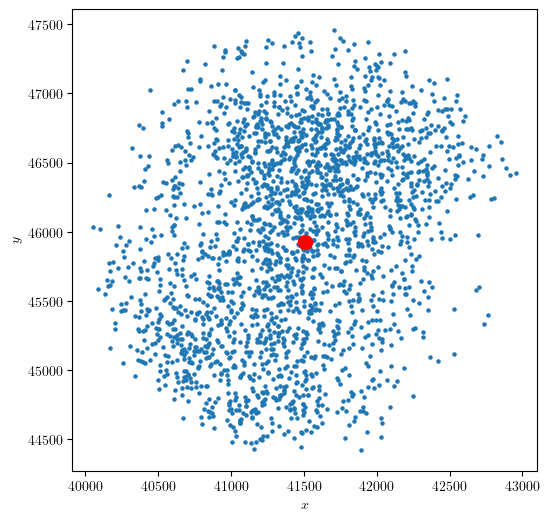

In [62]:
# try to visualize some result

member_pos = subhalo_pos[members]

plt.figure(figsize=(6,6))

plt.scatter(member_pos[:,0], member_pos[:,1], s=5)

plt.scatter(center[0], center[1], c="red", s=100)

plt.xlabel("$x$")
plt.ylabel("$y$")

plt.show()